<h1 align="center">Bird Audio CNN Classification</h1>

<p align="center">Chuyu Xiao</p>

# 1. Create a Project Folder

In [1]:
!mkdir bird_audio_cnn

Check:

In [2]:
!ls

bird_audio_cnn	sample_data


You should see:

bird_audio_cnn
sample_data

# 2. Create dataset.py

In [33]:
%%writefile bird_audio_cnn/dataset.py

import torch
import torchaudio
from torch.utils.data import Dataset
import torch.nn.functional as F


class BirdDatasetV2(Dataset):
    def __init__(
        self,
        file_paths,
        labels,
        sample_rate=32000,
        duration_seconds=5,
        n_fft=1024,
        hop_length=512,
        n_mels=64,
        silence_threshold=0.02
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.sample_rate = sample_rate
        self.target_samples = sample_rate * duration_seconds
        self.silence_threshold = silence_threshold

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def __len__(self):
        return len(self.file_paths)

    def to_mono(self, waveform):
        return waveform.mean(dim=0, keepdim=True)

    def resample_if_needed(self, waveform, sr):
        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sr,
                new_freq=self.sample_rate
            )
            waveform = resampler(waveform)

        return waveform

    def trim_silence(self, waveform):
        energy = waveform.abs().squeeze()

        active = energy > self.silence_threshold

        if active.sum() == 0:
            return waveform

        start = active.nonzero()[0].item()
        end = active.nonzero()[-1].item()

        return waveform[:, start:end + 1]

    def fix_waveform_length(self, waveform):
        length = waveform.shape[1]

        if length > self.target_samples:
            waveform = waveform[:, :self.target_samples]

        elif length < self.target_samples:
            pad_amount = self.target_samples - length
            waveform = F.pad(waveform, (0, pad_amount))

        return waveform

    def normalize_waveform(self, waveform):
        max_val = waveform.abs().max()

        if max_val > 0:
            waveform = waveform / max_val

        return waveform

    def __getitem__(self, idx):
        waveform, sr = torchaudio.load(self.file_paths[idx])

        waveform = self.to_mono(waveform)
        waveform = self.resample_if_needed(waveform, sr)
        waveform = self.normalize_waveform(waveform)
        waveform = self.trim_silence(waveform)
        waveform = self.fix_waveform_length(waveform)

        mel_spec = self.mel_transform(waveform)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return mel_spec, label

Overwriting bird_audio_cnn/dataset.py


# 3. Create model.py

This is a small Edge-AI style CNN.

In [4]:
%%writefile bird_audio_cnn/model.py

import torch
import torch.nn as nn


class BirdCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.AdaptiveAvgPool2d((4,4)),

            nn.Flatten(),

            nn.Linear(
                32*4*4,
                num_classes
            )
        )


    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc(x)

        return x

Writing bird_audio_cnn/model.py


# 4. Create utils.py

This will help visualize the input.

In [5]:
%%writefile bird_audio_cnn/utils.py

import matplotlib.pyplot as plt


def show_spectrogram(spec):

    plt.figure(figsize=(8,4))

    plt.imshow(
        spec.squeeze().numpy(),
        origin="lower",
        aspect="auto"
    )

    plt.colorbar()

    plt.title(
        "Mel Spectrogram"
    )

    plt.show()

Writing bird_audio_cnn/utils.py


# 5. Create train.py

This separates training logic from model logic.

In [27]:
%%writefile bird_audio_cnn/train.py

import torch


def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0

    for x, y in dataloader:

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss


def evaluate(model, dataloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in dataloader:

            pred = model(x)

            predicted = pred.argmax(dim=1)

            correct += (predicted == y).sum().item()

            total += y.size(0)

    return correct / total

Overwriting bird_audio_cnn/train.py


# 6. Verify the Files Exist

Expected:

dataset.py
model.py
train.py
utils.py

In [7]:
!ls bird_audio_cnn

dataset.py  model.py  train.py	utils.py


# 7. Execution

## 7.1 Import the programs

In [8]:
from bird_audio_cnn.model import BirdCNN
from bird_audio_cnn.utils import show_spectrogram

## 7.2 Create the model

In [9]:
model = BirdCNN(
    num_classes=5
)

print(model)

BirdCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=512, out_features=5, bias=True)
  )
)


## 7.3 Create Label Mapping

In [10]:
import os
from glob import glob

species = [
    "American_Robin",
    "Blue_Jay",
    "House_Sparrow",
    "Mourning_Dove",
    "Northern_Cardinal"
]

label_map = {name: idx for idx, name in enumerate(species)}
print(label_map)

{'American_Robin': 0, 'Blue_Jay': 1, 'House_Sparrow': 2, 'Mourning_Dove': 3, 'Northern_Cardinal': 4}


## 7.4 Upload and Unzip audio.zip from Google Drive

In [11]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Make sure that audio.zip is found in the drive directory.

In [12]:
!ls -lh /content/drive/MyDrive

total 1.7G
-rw------- 1 root root 361M Jul  3 02:41  audio.zip
drwx------ 2 root root 4.0K Jun 30 05:30 'Colab Notebooks'
-rw------- 1 root root 680M May  2 02:36 'IMG_8887 (1).mov'
-rw------- 1 root root 680M May  2 02:37  IMG_8887.mov


In [13]:
!unzip /content/drive/MyDrive/audio.zip -d .

Archive:  /content/drive/MyDrive/audio.zip
   creating: ./audio/
   creating: ./audio/American_Robin/
  inflating: ./audio/American_Robin/XC1047670 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC1049493 - American Robin - Turdus migratorius migratorius.wav  
  inflating: ./audio/American_Robin/XC1089129 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC660898 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC690092 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC716282 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC734182 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC744610 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC771920 - American Robin - Turdus migratorius.mp3  
  inflating: ./audio/American_Robin/XC774170 - American Robin - Turdus migratorius

## 7.5 Convert .MP3 to .WAV

Install ffmpeg

In [14]:
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


Convert all MP3s

In [15]:
import os
from glob import glob

for bird in os.listdir("audio"):

    mp3_files = glob(f"audio/{bird}/*.mp3")

    for mp3_file in mp3_files:

        wav_file = mp3_file.replace(".mp3", ".wav")

        !ffmpeg -i "$mp3_file" \
                -ac 1 \
                -ar 32000 \
                "$wav_file"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 7.6 Connect audio file paths

In [16]:
file_paths = []
labels = []

for bird in species:
    paths = glob(f"audio/{bird}/*.wav")

    for p in paths:
        file_paths.append(p)
        labels.append(label_map[bird])

print("Total files:", len(file_paths))
print(file_paths[:5])
print(labels[:5])

Total files: 70
['audio/American_Robin/XC660898 - American Robin - Turdus migratorius.wav', 'audio/American_Robin/XC771920 - American Robin - Turdus migratorius.wav', 'audio/American_Robin/XC1049493 - American Robin - Turdus migratorius migratorius.wav', 'audio/American_Robin/XC872369 - American Robin - Turdus migratorius.wav', 'audio/American_Robin/XC690092 - American Robin - Turdus migratorius.wav']
[0, 0, 0, 0, 0]


## 7.7 Create datasheet and dataloader

In [17]:
!grep -n "mean" bird_audio_cnn/dataset.py

40:        waveform = waveform.mean(dim=0, keepdim=True)
45:        mel_spec = mel_spec.mean(dim=0, keepdim=True)


In [34]:
import importlib
import bird_audio_cnn.dataset
importlib.reload(bird_audio_cnn.dataset)

from bird_audio_cnn.dataset import BirdDatasetV2
from torch.utils.data import DataLoader

dataset = BirdDatasetV2(file_paths, labels)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

x, y = next(iter(dataloader))

print(x.shape)
print(y.shape)

torch.Size([8, 1, 64, 313])
torch.Size([8])


## 7.8 Visualize one spectrogram

Label: tensor(0)


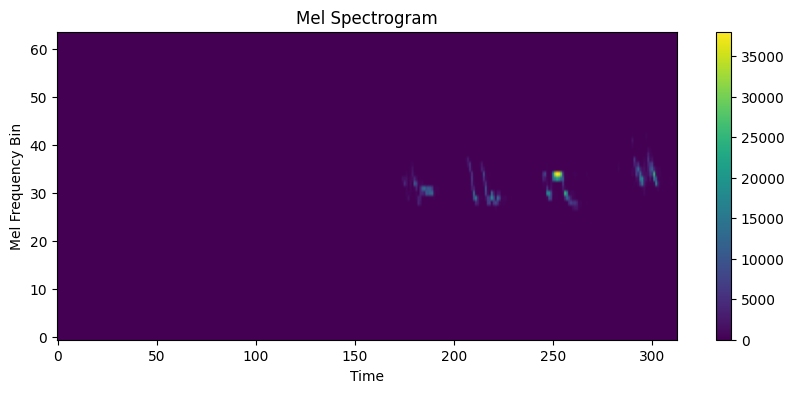

In [35]:
import matplotlib.pyplot as plt

x, y = dataset[0]

print("Label:", y)

plt.figure(figsize=(10,4))

plt.imshow(
    x.squeeze().numpy(),
    origin='lower',
    aspect='auto'
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency Bin")

plt.show()

## 7.9 Test model forward pass

In [36]:
from bird_audio_cnn.model import BirdCNN

model = BirdCNN(num_classes=5)

x, y = next(iter(dataloader))

output = model(x)

print(output.shape)

torch.Size([8, 5])


## 7.10 Train / Test split

In [37]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

In [38]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [39]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 56
Testing samples: 14


## 7.11 Train the Model

In [40]:
import importlib
import bird_audio_cnn.train

importlib.reload(bird_audio_cnn.train)

from bird_audio_cnn.train import (
    train_one_epoch,
    evaluate
)

In [41]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [42]:
for epoch in range(10):

    loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    acc = evaluate(
        model,
        test_loader
    )

    print(
        f"Epoch {epoch+1}: "
        f"Loss={loss:.3f}, "
        f"Accuracy={acc:.3f}"
    )

Epoch 1: Loss=127.434, Accuracy=0.357
Epoch 2: Loss=48.394, Accuracy=0.214
Epoch 3: Loss=25.564, Accuracy=0.429
Epoch 4: Loss=12.719, Accuracy=0.500
Epoch 5: Loss=13.382, Accuracy=0.500
Epoch 6: Loss=9.315, Accuracy=0.357
Epoch 7: Loss=7.216, Accuracy=0.357
Epoch 8: Loss=8.707, Accuracy=0.429
Epoch 9: Loss=5.199, Accuracy=0.429
Epoch 10: Loss=3.952, Accuracy=0.500
